In [1]:
from argparse import Namespace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.app.runtime import build_dataset, build_loader, load_defaults, load_run_vae
from src.modeling.phases import probabilities_to_calibrated_labels

In [2]:
RUN_DIR = ""  # latest available run
BATCH_SIZE = 2

In [3]:
runs = [p for p in (ROOT / "run").glob("*") if (p / "vae.yaml").is_file()]
run_dir = Path(RUN_DIR) if RUN_DIR else max(runs, key=lambda p: p.stat().st_mtime)
run_dir = run_dir if run_dir.is_absolute() else ROOT / run_dir

args = Namespace(**load_defaults(run_dir / "vae.yaml"))
args.data_dir = Path(args.data_dir)
args.data_dir = args.data_dir if args.data_dir.is_absolute() else ROOT / args.data_dir
args.batch_size = BATCH_SIZE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = build_dataset(args)
vae = load_run_vae(run_dir, device=device)

print("run:", run_dir.name)

run: 20260715-115950-207780


pixel accuracy: 97.85% | MAE: 0.0288


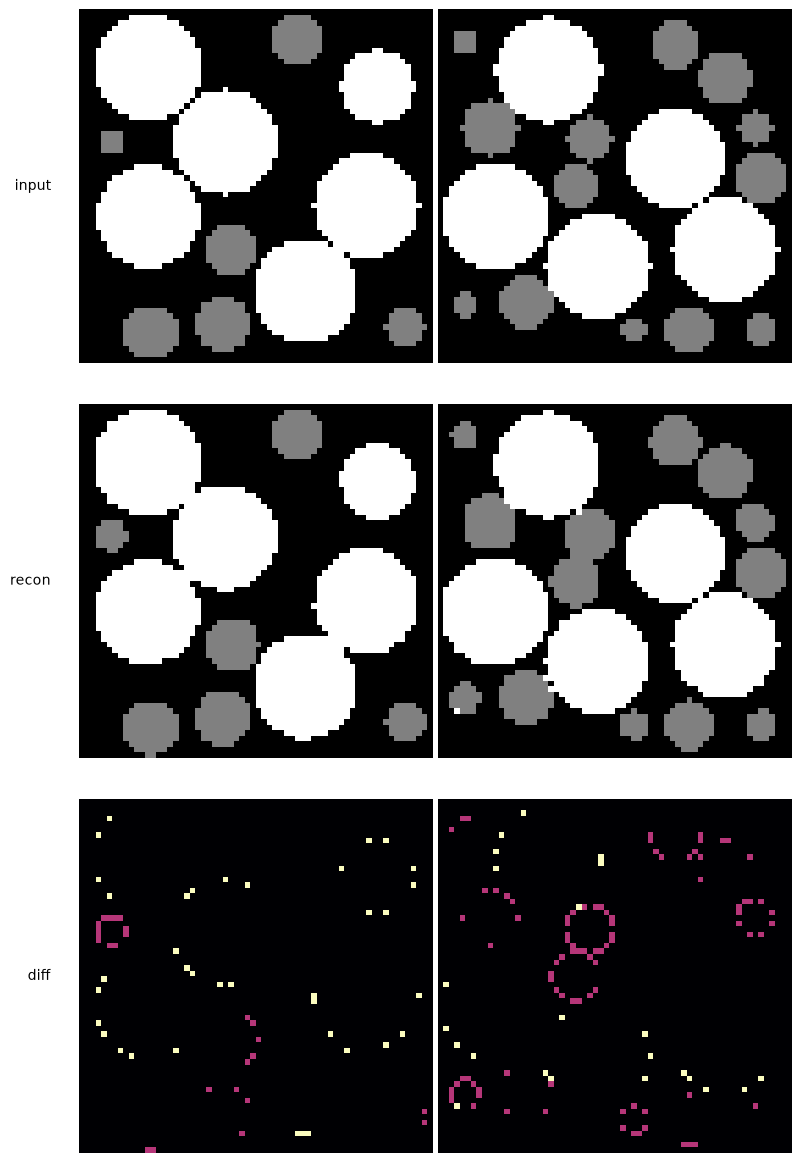

In [4]:
batch, _ = next(build_loader(dataset, args, device=torch.device("cpu")))
with torch.no_grad():
    latent, _ = vae.encode(batch.to(device))
    probabilities = vae.decode_probs(latent)

recon = probabilities_to_calibrated_labels(
    probabilities, args.num_phases
).cpu().float()
diff = (recon - batch).abs()
pixel_accuracy = (recon == batch).float().mean().item()
mae = diff.mean().item()

print(f"pixel accuracy: {pixel_accuracy:.2%} | MAE: {mae:.4f}")

n = min(2, batch.shape[0])
phase_vmax = float(args.num_phases - 1)
diff_vmax = max(float(diff.max()), 1.0)
rows = [
    ("input", batch[:n, 0], "gray"),
    ("recon", recon[:n, 0], "gray"),
    ("diff", diff[:n, 0], "magma"),
]

fig, axes = plt.subplots(len(rows), n, figsize=(8, 12), squeeze=False)
for ax in axes.ravel():
    ax.axis("off")
for row, (label, images, cmap) in enumerate(rows):
    axes[row, 0].text(
        -0.08,
        0.5,
        label,
        transform=axes[row, 0].transAxes,
        ha="right",
        va="center",
    )
    for column in range(n):
        axes[row, column].imshow(
            images[column],
            cmap=cmap,
            vmin=0,
            vmax=diff_vmax if label == "diff" else phase_vmax,
            interpolation="nearest",
        )
plt.tight_layout()